### Data Acquisition

In [4]:
#import libraries for data acquisition
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#loading the data set

df = pd.read_csv('train.csv')

#Dataset Dimension
print("Dataset dimensions (rows, columns", df.shape)

#print Column name
print("\nColumn names:")
print(df.columns.tolist())

df.head()

df.dtypes


Dataset dimensions (rows, columns (891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

### Detecting missing values



In [11]:
# Count missing values per column
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Percentage': missing_percent,
    'Missing Count': missing
})

print(missing_table)

df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Cabin'], errors='ignore')
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

#prints duplicates
print("Duplicated rows:", df.duplicated().sum())
print(df.isnull().sum())
print("\nNew dimensions:", df.shape)

             Missing Percentage  Missing Count
PassengerId                 0.0              0
Survived                    0.0              0
Pclass                      0.0              0
Name                        0.0              0
Sex                         0.0              0
Age                         0.0              0
SibSp                       0.0              0
Parch                       0.0              0
Ticket                      0.0              0
Fare                        0.0              0
Embarked                    0.0              0
Duplicated rows: 0
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

New dimensions: (891, 11)


### Data Visualisation

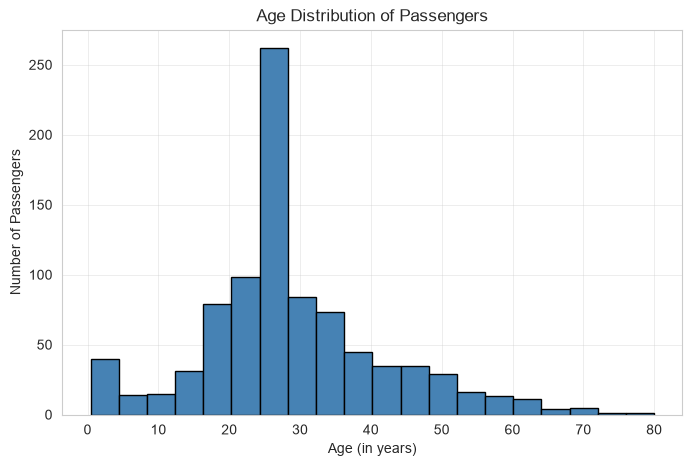

In [12]:
sns.set_style('whitegrid')

#Histogram of passenger ages
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
plt.title("Age Distribution of Passengers")
plt.xlabel("Age (in years)")
plt.ylabel("Number of Passengers")
plt.show()

### BARCHART FOR PASSENGER DISTRIBUTION

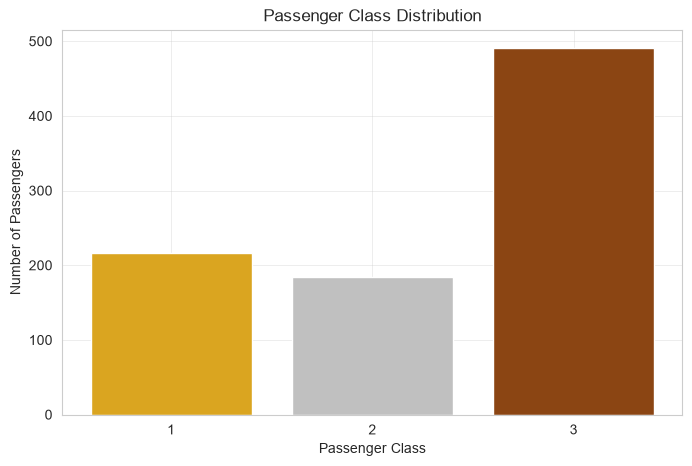

In [13]:
plt.figure(figsize=(8, 5))
class_counts = df['Pclass'].value_counts().sort_index()
plt.bar(class_counts.index.astype(str), class_counts.values,
        color=['goldenrod', 'silver', 'saddlebrown'])
plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

### Boxplot of age by passenger class


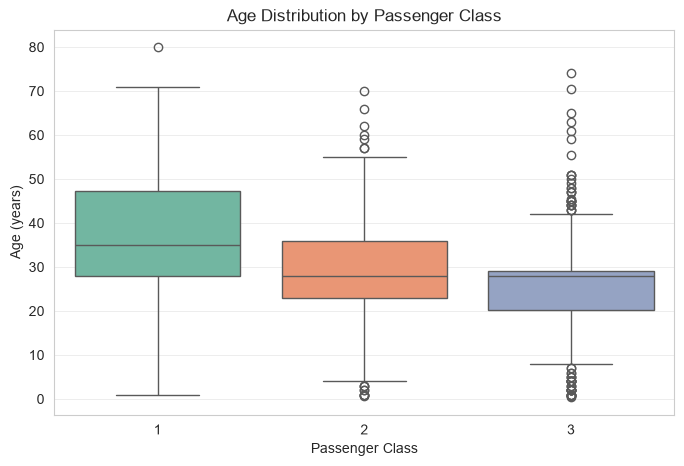

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Age', data=df, hue='Pclass', palette='Set2', legend=False)
plt.title('Age Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Age (years)')
plt.show()

 ### Scatter plot of Age vs Fare


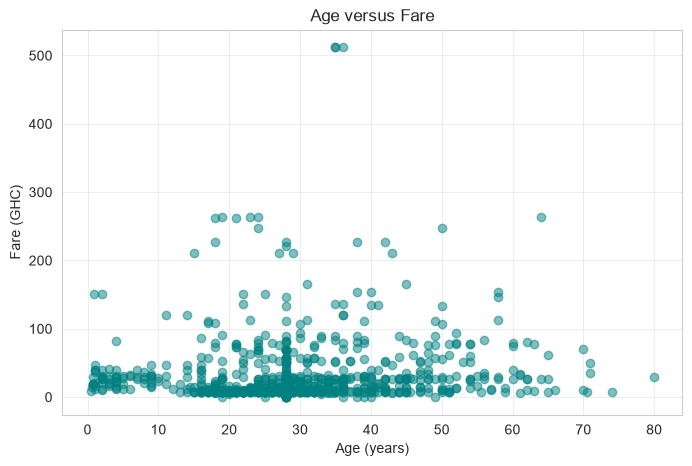

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Fare'], alpha=0.5, color='teal')
plt.title('Age versus Fare')
plt.xlabel('Age (years)')
plt.ylabel('Fare (GHC)')
plt.show()

### Correlation heatmap

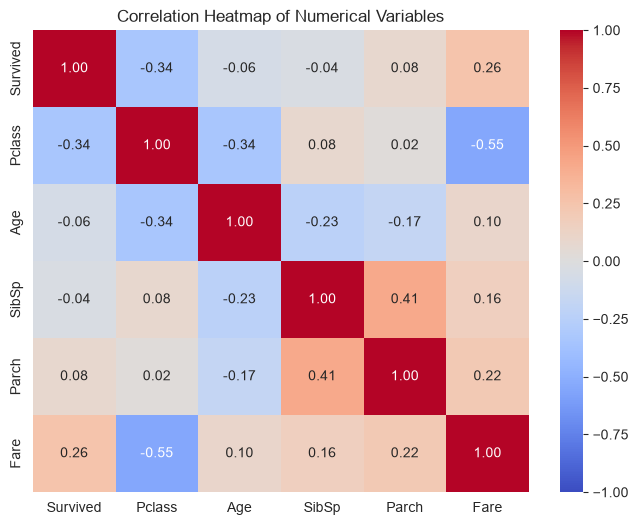

In [18]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['PassengerId'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Pairplot of selected numerical variables

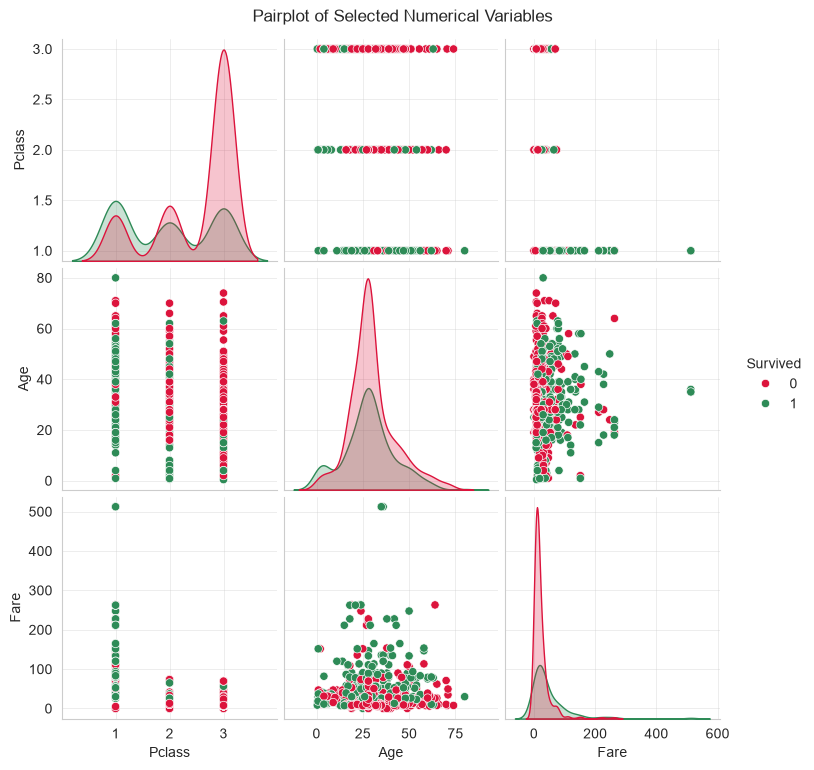

In [19]:
selected = df[['Survived', 'Pclass', 'Age', 'Fare']]
sns.pairplot(selected, hue='Survived', palette={0: 'crimson', 1: 'seagreen'})
plt.suptitle('Pairplot of Selected Numerical Variables', y=1.02)
plt.show()

In [20]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
df.describe(include='str')

,Name,Sex,Ticket,Embarked
count,891,891,891,891
unique,891,2,681,3
top,"Braund, Mr. Owen Harris",male,347082,S
freq,1,577,7,646


### Frequency Distribution


In [23]:
for col in ['Survived', 'Pclass', 'Sex', 'Embarked']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).round(3) * 100)


--- Survived ---
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.6
1    38.4
Name: proportion, dtype: float64

--- Pclass ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Pclass
3    55.1
1    24.2
2    20.7
Name: proportion, dtype: float64

--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64
Sex
male      64.8
female    35.2
Name: proportion, dtype: float64

--- Embarked ---
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64
Embarked
S    72.5
C    18.9
Q     8.6
Name: proportion, dtype: float64


### Correlation analysis

In [24]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['PassengerId'])
corr_matrix = numeric_df.corr()
print(corr_matrix.round(3))

          Survived  Pclass    Age  SibSp  Parch   Fare
Survived     1.000  -0.338 -0.065 -0.035  0.082  0.257
Pclass      -0.338   1.000 -0.340  0.083  0.018 -0.549
Age         -0.065  -0.340  1.000 -0.233 -0.172  0.097
SibSp       -0.035   0.083 -0.233  1.000  0.415  0.160
Parch        0.082   0.018 -0.172  0.415  1.000  0.216
Fare         0.257  -0.549  0.097  0.160  0.216  1.000


### Strongest positive and negative correlations

In [25]:
# Unstack the matrix into pairs, remove self-correlations (which are always 1.0)
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]

print("Strongest positive:", corr_pairs.idxmax(), round(corr_pairs.max(), 3))
print("Strongest negative:", corr_pairs.idxmin(), round(corr_pairs.min(), 3))

Strongest positive: ('SibSp', 'Parch') 0.415
Strongest negative: ('Pclass', 'Fare') -0.549


### Three important statistical findings

1. Survival was the exception, not the rule. Only 38.4% of passengers in the dataset survived — consistent with the historical disaster, where lifeboat capacity covered barely half of those aboard.
2. Social class correlated with survival. The negative correlation between Pclass and Survived (r ≈ -0.34), combined with the fare–survival positive correlation (r ≈ 0.26), suggests wealthier passengers had systematically better survival odds — plausibly due to cabin proximity to the boat deck and priority in evacuation. A supporting number you can compute: survival rate by class You'll see roughly 63% (1st), 47% (2nd), 24% (3rd) — a stark gradient worth quoting.

In [26]:
print(df.groupby('Pclass')['Survived'].mean().round(3) * 100)


Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


3. Fare was heavily right-skewed. Median £14 vs mean £32, with a maximum of £512 — a small wealthy elite paid dramatically more than typical passengers. This skew is also why we preferred the median when reasoning about "typical" values.
A worthwhile bonus (feel free to include it): sex was the strongest survival factor of all
≈ 74% of women survived vs 19% of men — "women and children first" is visible right there in the data. Sex doesn't appear in the correlation matrix because it's stored as text, which is exactly the problem we'll solve in Task 5 when we encode it for the machine learning model.

In [27]:
print(df.groupby('Sex')['Survived'].mean().round(3) * 100)


Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


### Machine Learning


what is classification?
We want to predict a category (survived: yes/no) from other variables. That's classification — as opposed to regression, which predicts a number. Our workflow: show the model many passengers whose outcomes we know (training), then test it on passengers it has never seen, and measure how well it does.

Concept: what does Logistic Regression actually do?
Despite the name, it's a classifier. It computes a weighted sum of the input features (like a score), then squashes that score through the sigmoid function into a value between 0 and 1, interpreted as the probability of survival. If the probability is above 0.5, predict survived; otherwise, died. Training is the process of finding the weights that make these probabilities match the training data as closely as possible. The weights are also interpretable: a positive weight means "this feature pushes toward survival."




Step 1 — Select predictor variables

Our earlier analysis tells us exactly what matters: Sex (74% vs 19% survival!), Pclass (63/47/24% gradient), Fare, and Age. We'll also include SibSp and Parch (family size had some effect). We exclude PassengerId (meaningless row number), Name and Ticket (unique text strings with no general pattern for a linear model), and Embarked we could include, but let's keep the model simple and defensible.


But there's a problem: Sex is text ("male"/"female"), and logistic regression needs numbers. We encode it:

Convention: capital X for the feature matrix (2-D), lowercase y for the target vector (1-D).

In [34]:
model_df = df.copy()

model_df['Sex'] = model_df['Sex'].map({'male': 0, 'female': 1})

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
x = model_df[features]
y = model_df['Survived']




Step 2: Train and Test split

Why we split: if we tested the model on the same data it trained on, we'd get a flattering, dishonest score — like grading students on the exact questions they practised. We hold out a portion the model never sees, to measure generalisation.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (712, 6)
Testing set: (179, 6)


Step 3: Train the classifier


In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

.fit() is where learning happens — scikit-learn iteratively adjusts the weights to fit the training data. max_iter=1000 raises the iteration cap from the default 100, because our features are on wildly different scales (Fare up to 512, Sex just 0/1), which slows convergence. Without it you'd likely see a ConvergenceWarning — and you now know how we feel about warnings.

Step 4: Predict the test

In [36]:
y_pred = model.predict(X_test)

For each of the 179 held-out passengers, the model outputs 0 or 1.

Step 5: Evaluate

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8101

Confusion Matrix:
 [[92 13]
 [21 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

